<a href="https://colab.research.google.com/github/anshudahiya121/Python_1/blob/main/Python_pandas_matplotlib_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
summary_df=pd.read_csv("/content/online_learning_capstone_day 2.csv")

In [ ]:
summary_df

,User_ID,Signup_Date,Country,Subscription_Plan,Device_Type,Course_Category,Courses_Enrolled,Courses_Completed,Avg_Watch_Time_Hours,Active_Days,Monthly_Fee,Revenue,Quiz_Score,Churned
0,U00001,2024-04-12,USA,Free,Desktop,SQL,6,5,29.5,82,0,15,83.1,No
1,U00002,2024-12-14,USA,Basic,Mobile,Machine Learning,11,1,15.3,289,19,173,73.8,No
2,U00003,2024-09-27,Australia,Basic,Desktop,Machine Learning,11,3,19.7,186,19,31,68.7,No
3,U00004,2024-04-16,India,Free,Mobile,Excel,11,4,29.6,89,0,24,100.0,No
4,U00005,2024-03-12,India,Basic,Mobile,Data Science,11,2,23.6,160,19,50,95.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,U04996,2024-10-02,India,Free,Desktop,Python,2,1,21.0,81,0,5,83.0,No
4996,U04997,2024-02-19,USA,Pro,Desktop,Python,8,2,22.0,42,49,65,77.1,No
4997,U04998,2024-12-23,Germany,Pro,Mobile,Power BI,10,3,21.3,151,49,55,77.3,Yes
4998,U04999,2024-08-03,Canada,Pro,Mobile,SQL,9,3,22.4,73,49,591,70.2,No


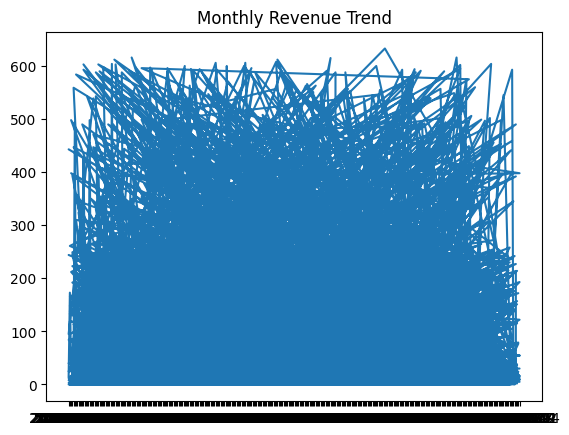

In [ ]:
plt.plot(summary_df['Signup_Date'], summary_df['Revenue'])
plt.title('Monthly Revenue Trend');

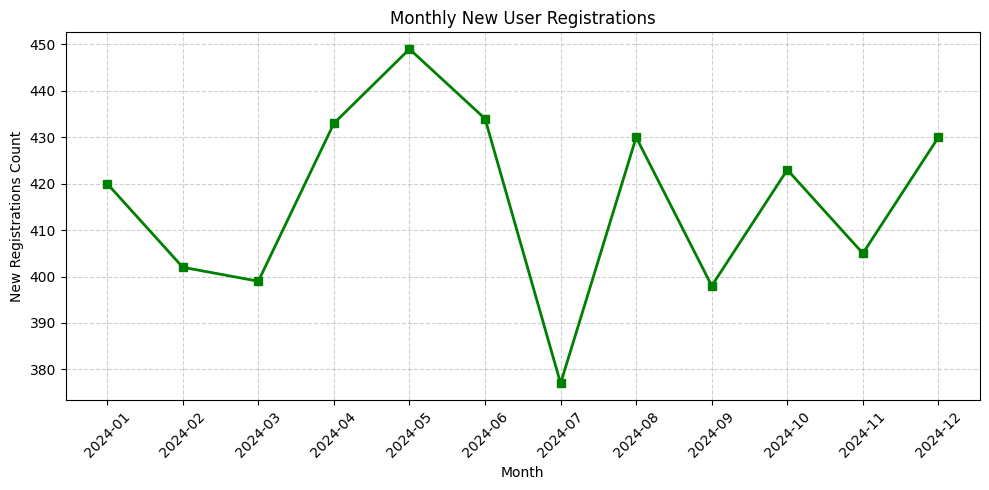

In [ ]:
summary_df['Signup_Date'] = pd.to_datetime(summary_df['Signup_Date'])
monthly_users = summary_df.groupby(summary_df['Signup_Date'].dt.to_period('M')).size().reset_index(name='New_Registrations')
monthly_users['Month'] = monthly_users['Signup_Date'].dt.strftime('%Y-%m')

plt.figure(figsize=(10, 5))
plt.plot(monthly_users['Month'], monthly_users['New_Registrations'], marker='s', color='g', linewidth=2)
plt.title('Monthly New User Registrations')
plt.xlabel('Month')
plt.ylabel('New Registrations Count')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

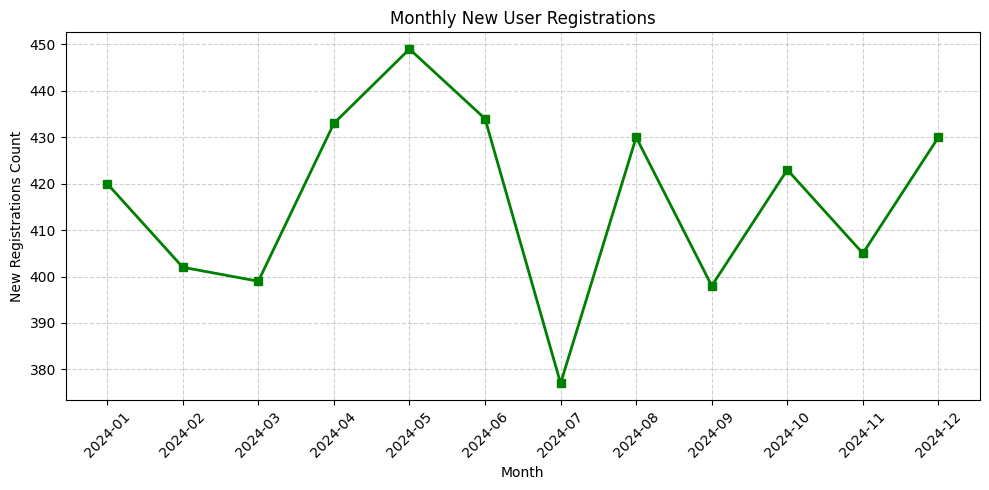

In [ ]:
summary_df['Signup_Date'] = pd.to_datetime(summary_df['Signup_Date'])
summary_df['Month'] = summary_df['Signup_Date'].dt.strftime('%Y-%m')

# Group and count unique users per month
monthly_users = summary_df.groupby('Month')['User_ID'].count().reset_index(name='New_Registrations').sort_values('Month')

# Plot the registrations trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_users['Month'], monthly_users['New_Registrations'], marker='s', color='g', linewidth=2)
plt.title('Monthly New User Registrations')
plt.xlabel('Month')
plt.ylabel('New Registrations Count')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

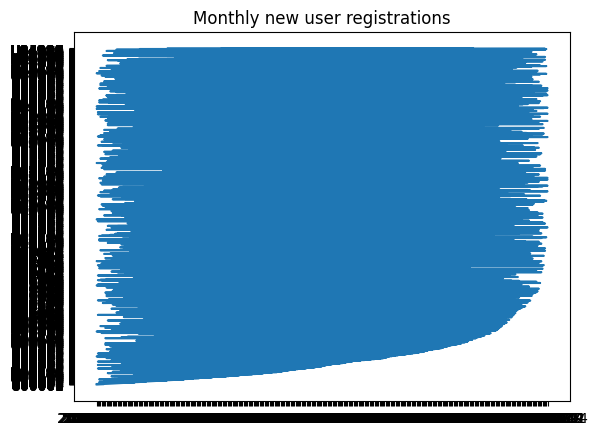

In [ ]:
plt.plot(summary_df['Signup_Date'], summary_df['User_ID'])
plt.title('Monthly new user registrations');

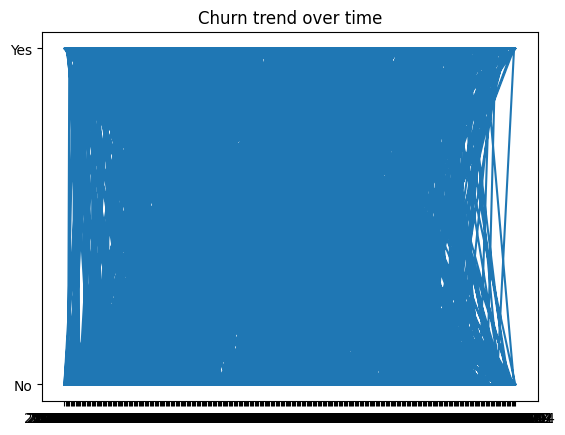

In [ ]:
plt.plot(summary_df['Signup_Date'], summary_df['Churned'])
plt.title('Churn trend over time');

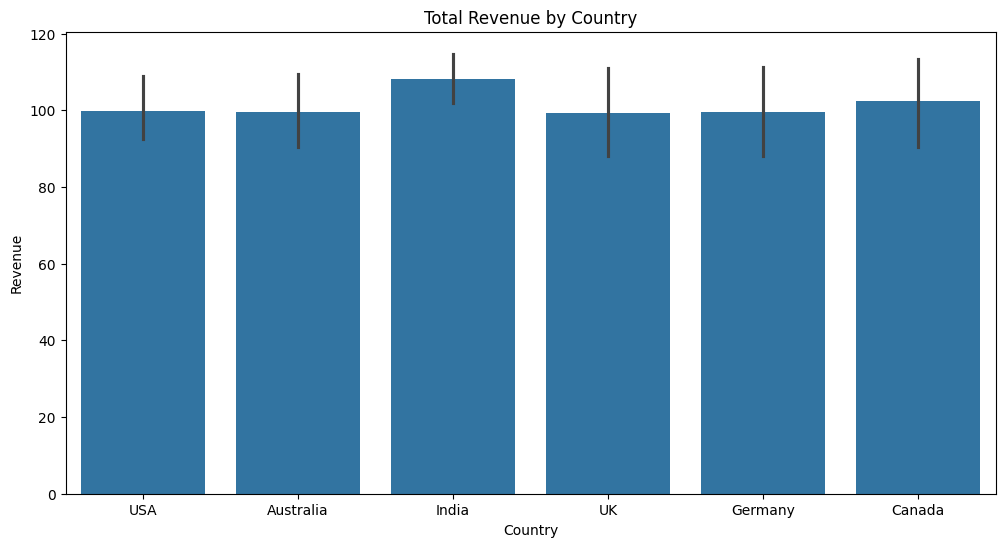

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x="Country",y="Revenue", data=summary_df)
plt.title('Total Revenue by Country');

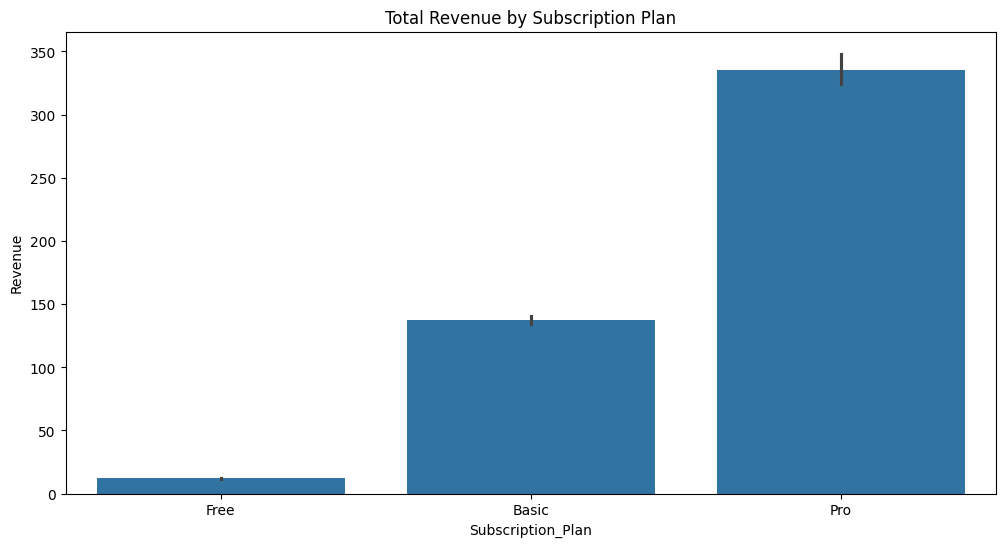

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x="Subscription_Plan",y="Revenue", data=summary_df)
plt.title('Total Revenue by Subscription Plan');

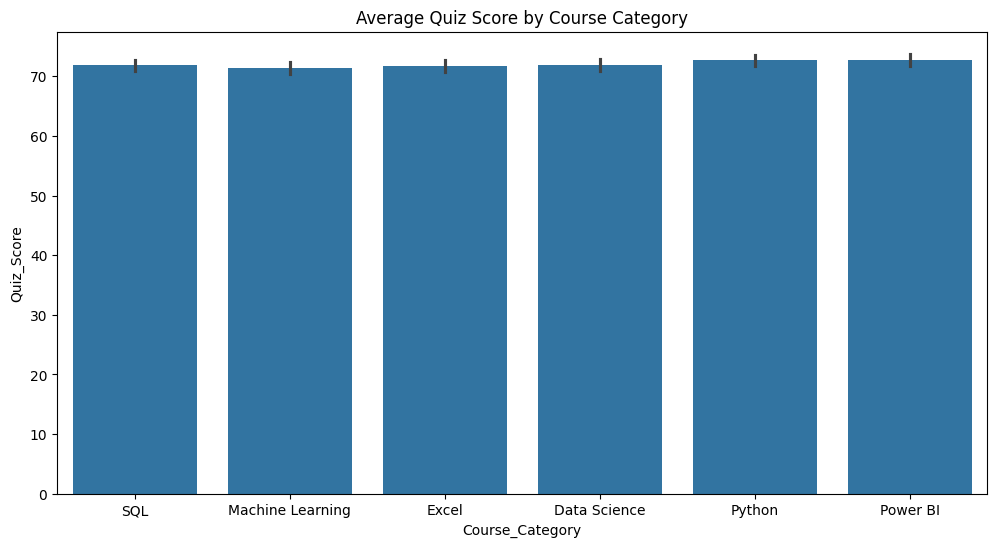

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Course_Category', y='Quiz_Score', data=summary_df)
plt.title('Average Quiz Score by Course Category');

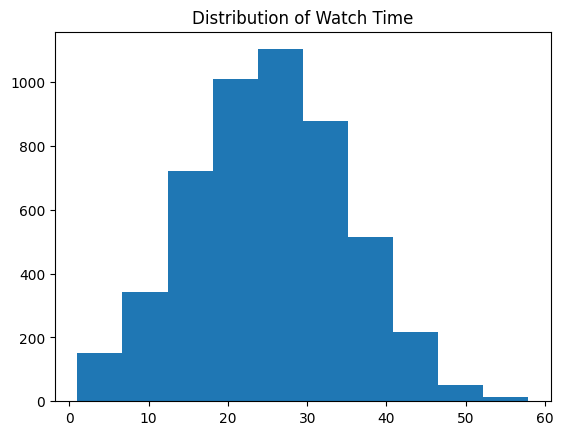

In [ ]:
plt.title("Distribution of Watch Time")
plt.hist(summary_df.Avg_Watch_Time_Hours);

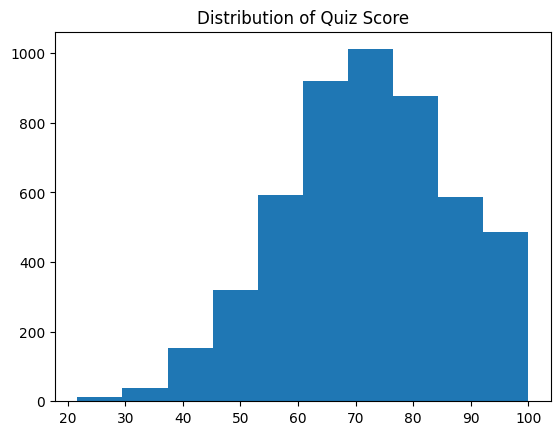

In [ ]:
plt.title("Distribution of Quiz Score")
plt.hist(summary_df.Quiz_Score);

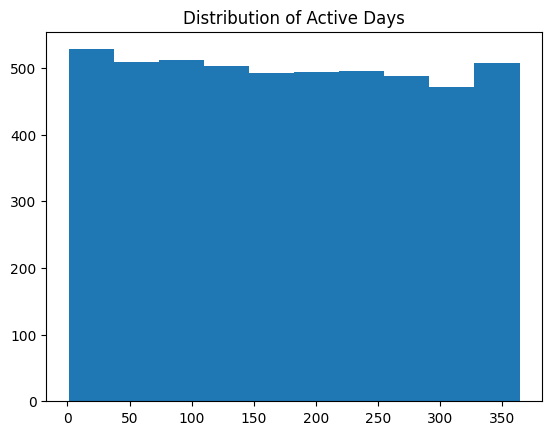

In [ ]:
plt.title("Distribution of Active Days")
plt.hist(summary_df.Active_Days);

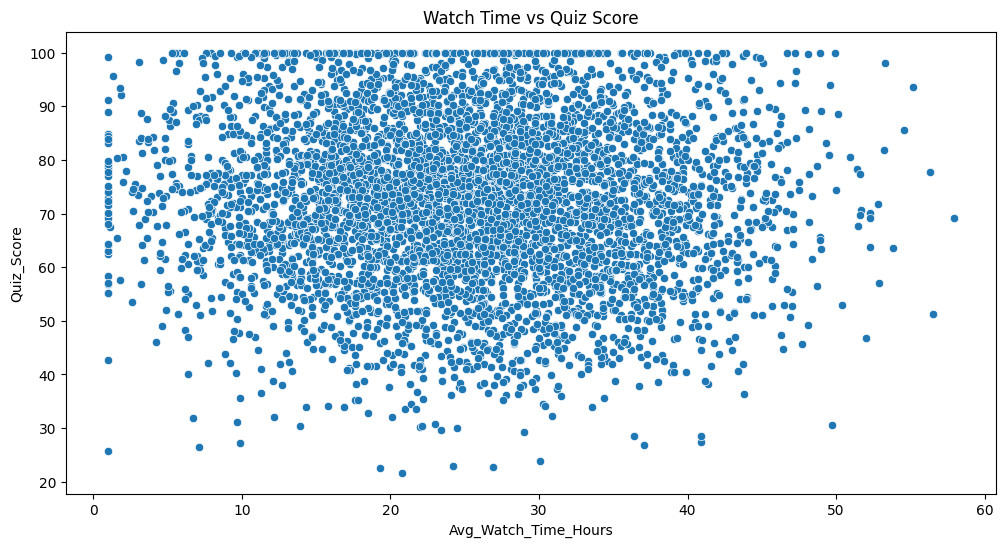

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Watch Time vs Quiz Score')
sns.scatterplot(x='Avg_Watch_Time_Hours', y='Quiz_Score', data=summary_df);

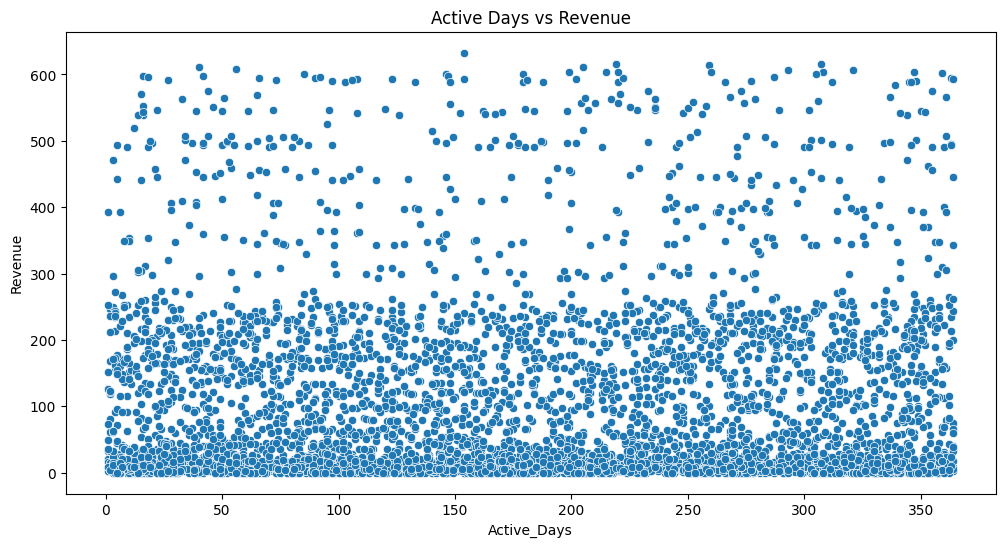

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Active Days vs Revenue')
sns.scatterplot(x='Active_Days', y='Revenue', data=summary_df);

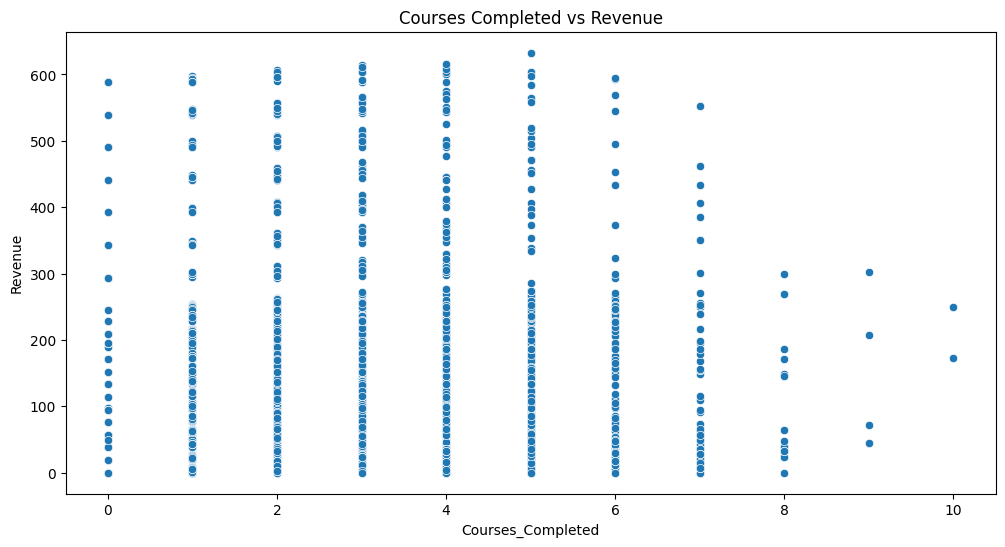

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Courses Completed vs Revenue')
sns.scatterplot(x='Courses_Completed', y='Revenue', data=summary_df);

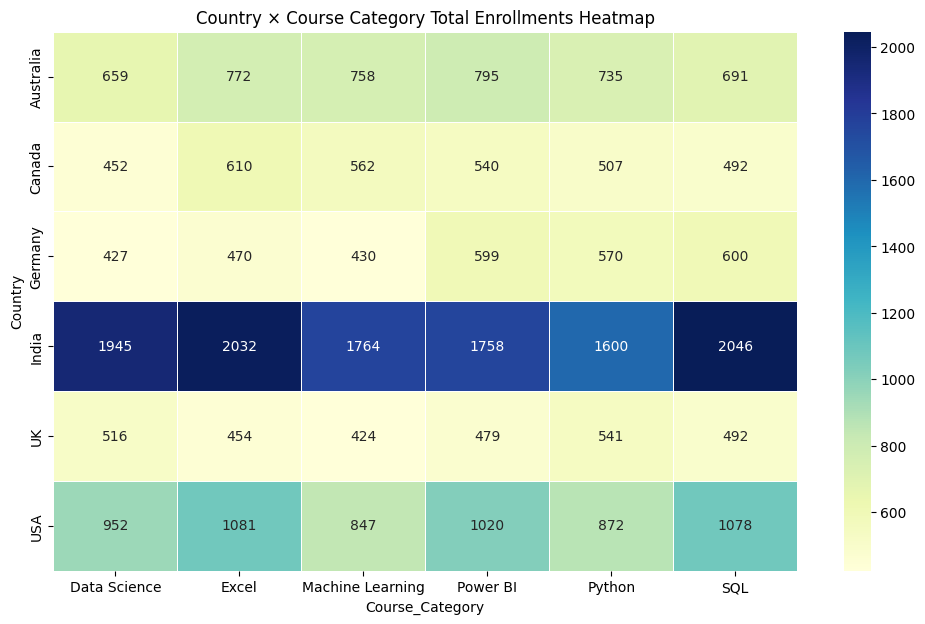

In [ ]:
pivot_df = summary_df.pivot_table(index='Country', columns='Course_Category', values='Courses_Enrolled', aggfunc='sum')
plt.figure(figsize=(12, 7))
sns.heatmap(pivot_df, annot=True, fmt="g", cmap='YlGnBu', linewidths=0.5)
plt.title('Country × Course Category Total Enrollments Heatmap');
